# **SEASONALITY ANALYSIS**

## **IMPORTS**

In [16]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

## **DATASET LOADING**

In [22]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df = bike_sharing.data.original

# variable information 
print(bike_sharing.variables)

print(df.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

## **ANALYSIS**

### General visualization

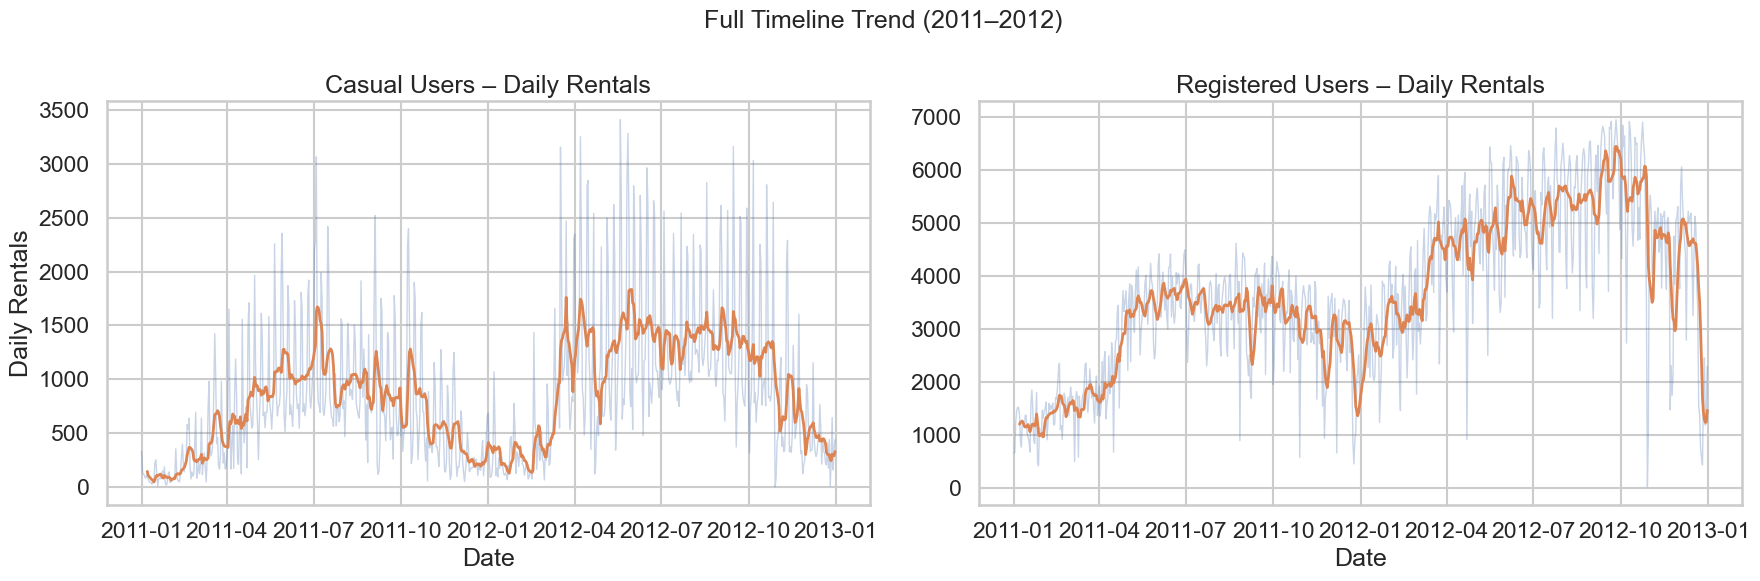

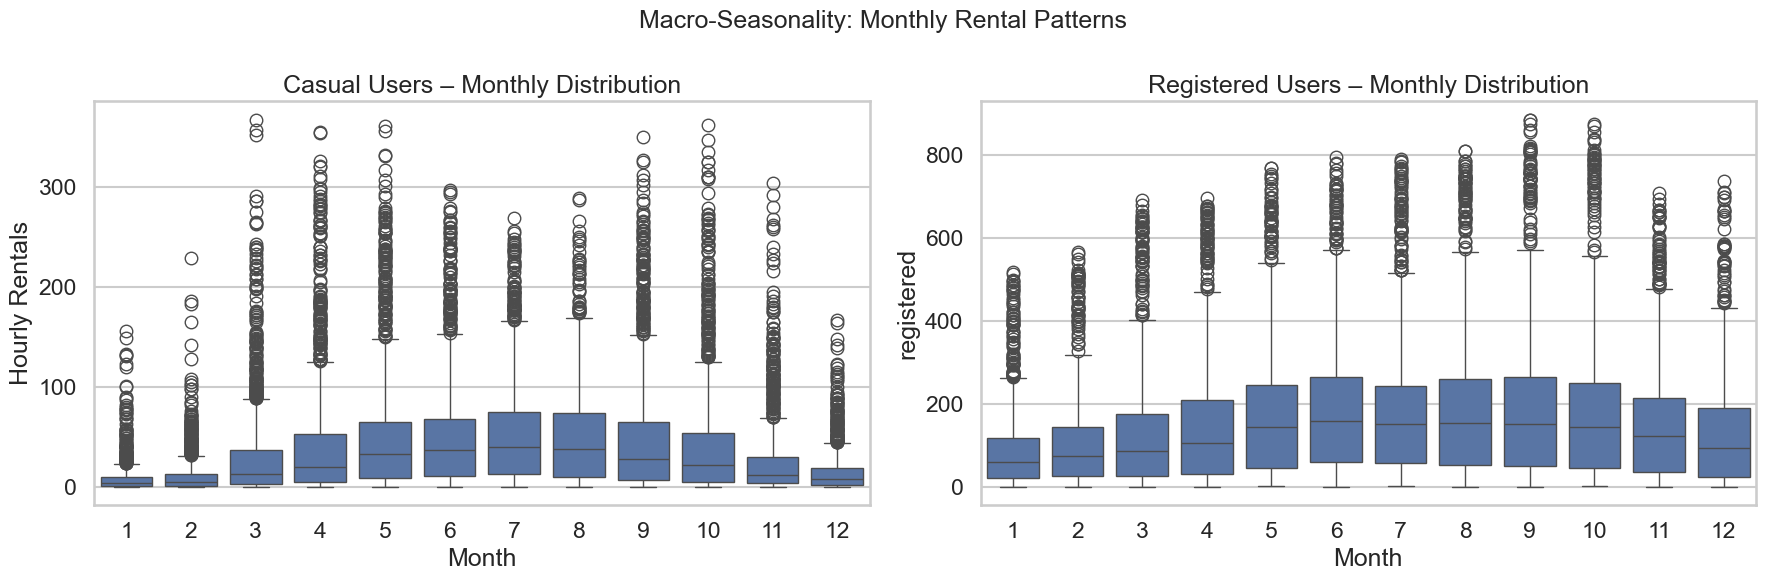

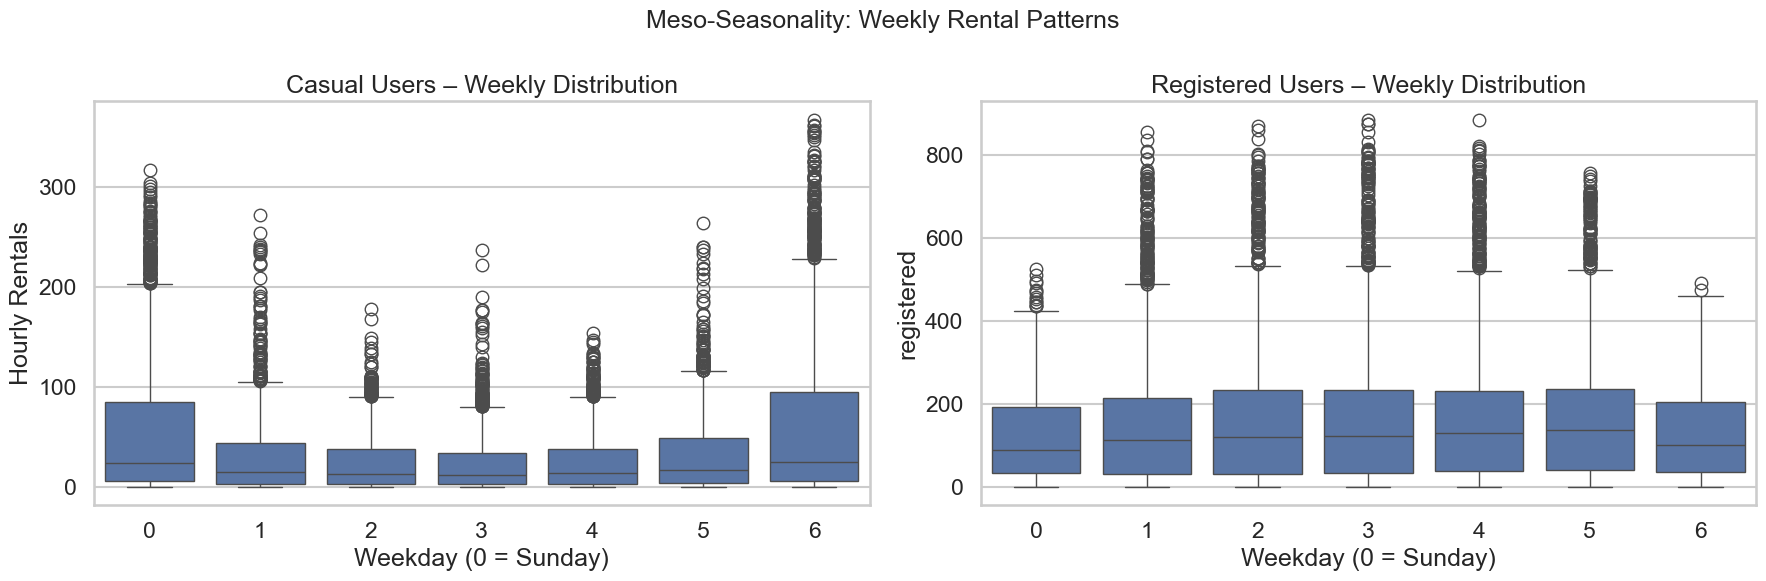

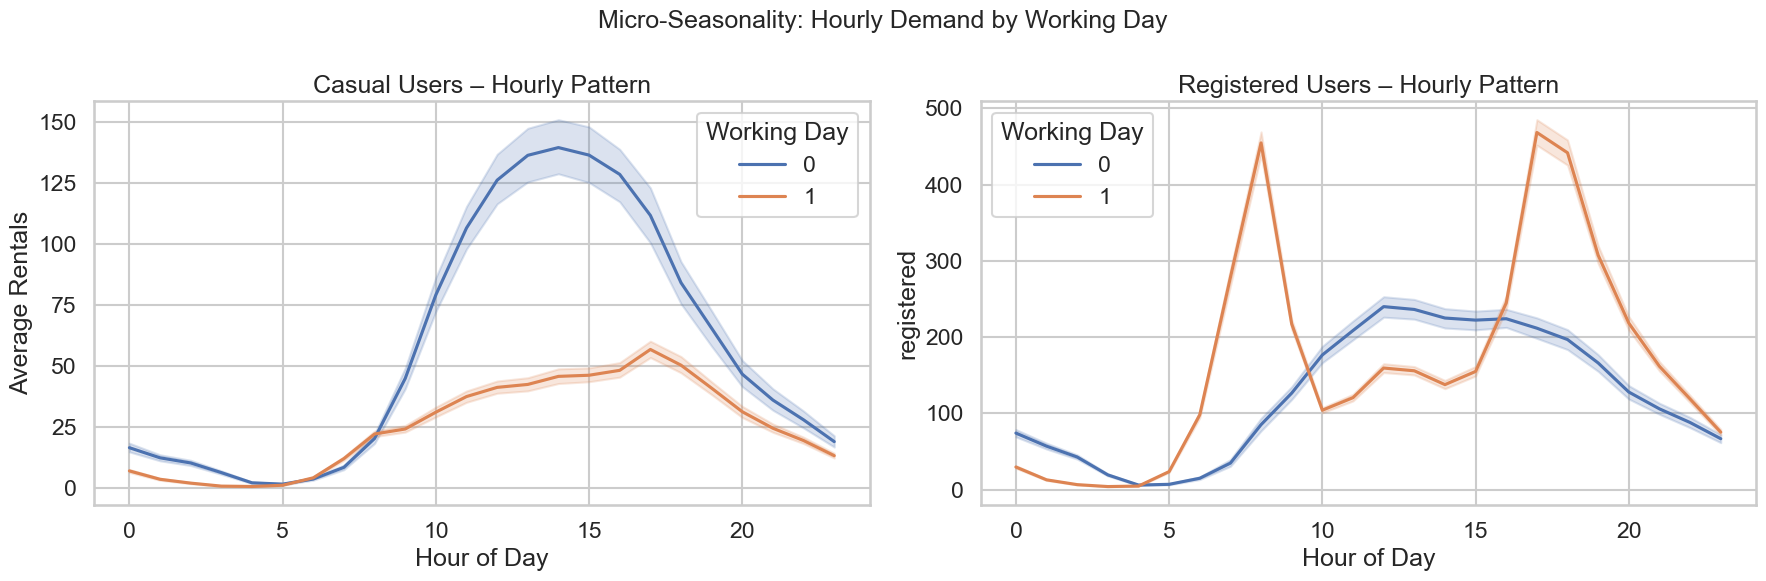

In [23]:
# ------------------------------------------------------------
# General plotting configuration
# ------------------------------------------------------------
sns.set(style="whitegrid", context="talk")

# Ensure datetime format
df["dteday"] = pd.to_datetime(df["dteday"])


# ============================================================
# 1. FULL TIMELINE (GLOBAL TREND)
# Daily aggregated time series across the full 2 years
# ============================================================

# Aggregate hourly data to daily totals
daily_df = (
    df.groupby("dteday")[["casual", "registered"]]
    .sum()
    .reset_index()
)

# Rolling mean for smoother visualization
daily_df["casual_roll7"] = daily_df["casual"].rolling(window=7).mean()
daily_df["registered_roll7"] = daily_df["registered"].rolling(window=7).mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Casual
axes[0].plot(daily_df["dteday"], daily_df["casual"], alpha=0.3, linewidth=1)
axes[0].plot(daily_df["dteday"], daily_df["casual_roll7"], linewidth=2)
axes[0].set_title("Casual Users – Daily Rentals")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily Rentals")

# Registered
axes[1].plot(daily_df["dteday"], daily_df["registered"], alpha=0.3, linewidth=1)
axes[1].plot(daily_df["dteday"], daily_df["registered_roll7"], linewidth=2)
axes[1].set_title("Registered Users – Daily Rentals")
axes[1].set_xlabel("Date")

fig.suptitle("Full Timeline Trend (2011–2012)", fontsize=18)
plt.tight_layout()
plt.show()


# ============================================================
# 2. MACRO-SEASONALITY (MONTHLY PATTERN)
# Distribution of rentals across months
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Casual
sns.boxplot(
    data=df,
    x="mnth",
    y="casual",
    ax=axes[0]
)
axes[0].set_title("Casual Users – Monthly Distribution")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Hourly Rentals")

# Registered
sns.boxplot(
    data=df,
    x="mnth",
    y="registered",
    ax=axes[1]
)
axes[1].set_title("Registered Users – Monthly Distribution")
axes[1].set_xlabel("Month")

fig.suptitle("Macro-Seasonality: Monthly Rental Patterns", fontsize=18)
plt.tight_layout()
plt.show()


# ============================================================
# 3. MESO-SEASONALITY (WEEKLY PATTERN)
# Distribution across days of the week
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Casual
sns.boxplot(
    data=df,
    x="weekday",
    y="casual",
    ax=axes[0]
)
axes[0].set_title("Casual Users – Weekly Distribution")
axes[0].set_xlabel("Weekday (0 = Sunday)")
axes[0].set_ylabel("Hourly Rentals")

# Registered
sns.boxplot(
    data=df,
    x="weekday",
    y="registered",
    ax=axes[1]
)
axes[1].set_title("Registered Users – Weekly Distribution")
axes[1].set_xlabel("Weekday (0 = Sunday)")

fig.suptitle("Meso-Seasonality: Weekly Rental Patterns", fontsize=18)
plt.tight_layout()
plt.show()


# ============================================================
# 4. MICRO-SEASONALITY (HOURLY PATTERN CONDITIONED BY WORKDAY)
# Average hourly demand split by working day vs non-working day
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Casual
sns.lineplot(
    data=df,
    x="hr",
    y="casual",
    hue="workingday",
    estimator="mean",
    errorbar="ci",
    ax=axes[0]
)
axes[0].set_title("Casual Users – Hourly Pattern")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Rentals")
axes[0].legend(title="Working Day")

# Registered
sns.lineplot(
    data=df,
    x="hr",
    y="registered",
    hue="workingday",
    estimator="mean",
    errorbar="ci",
    ax=axes[1]
)
axes[1].set_title("Registered Users – Hourly Pattern")
axes[1].set_xlabel("Hour of Day")
axes[1].legend(title="Working Day")

fig.suptitle("Micro-Seasonality: Hourly Demand by Working Day", fontsize=18)
plt.tight_layout()
plt.show()